# Screened Root Population Exploration

This notebook is an exploratory/archival record of how I examined the conservatively vascular-screened root-level nucleus population from Notebook 05 and compared it with the existing CA3 cell annotation table. The annotation CSV is used only as context for roots already annotated as CA3 cells; unlabeled screened roots are not interpreted as glia or any other cell class here.

The later Plotly sections show the path from basic feature summaries and 1D distribution checks toward a useful 3D centroid view. Notebook 07 carries that visualization approach forward in a cleaner form.


## Stage A: Load Screened Roots and Annotation Table

I first verified that the screened-root table and annotation CSV loaded cleanly, normalized root IDs, and checked the overlap between the two tables. The overlap is used only to divide roots into `annotated_neuron` and `unlabeled` groups for exploratory comparison; it is not cell typing for the unlabeled population.

In [1]:
import sys
from pathlib import Path

import pandas as pd


def find_project_root(start=Path.cwd().resolve()):
    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "helpers").is_dir() and (candidate / "data").is_dir():
            return candidate
    raise RuntimeError(
        "Could not find the Pyr project root. Expected a parent directory containing "
        "notebooks/helpers and data."
    )


project_root = find_project_root()
helpers_dir = project_root / "notebooks" / "helpers"
if str(helpers_dir) not in sys.path:
    sys.path.insert(0, str(helpers_dir))

from path_behavior import format_path, print_path

# Set to True to show full absolute paths in user-facing notebook output.
show_full_path = False
overwrite_existing = False


In [2]:
screened_root_parquet_path = project_root / "data" / "nuclei" / "c3_nuclei_root_features_screened_mat195.parquet"
annotation_csv_path = project_root / "data" / "mouse_hippocampus_ca3_cell_annotations_export.csv"

print_path("screened root Parquet", screened_root_parquet_path, project_root, show_full_path)
print_path("annotation CSV", annotation_csv_path, project_root, show_full_path)


screened root Parquet: data\nuclei\c3_nuclei_root_features_screened_mat195.parquet
annotation CSV: data\mouse_hippocampus_ca3_cell_annotations_export.csv


In [3]:
screened_root_df = pd.read_parquet(screened_root_parquet_path)
annotation_df = pd.read_csv(annotation_csv_path)

print(f"screened_root_df shape: {screened_root_df.shape}")
print(f"annotation_df shape: {annotation_df.shape}")


screened_root_df shape: (13860, 20)
annotation_df shape: (2764, 10)


In [4]:
print("screened_root_df columns:")
print(screened_root_df.columns.tolist())

print("annotation_df columns:")
print(annotation_df.columns.tolist())


screened_root_df columns:
['pt_root_id', 'nuclei_rows', 'unique_supervoxels', 'nucleus_volume_sum', 'nucleus_volume_max', 'nucleus_volume_median', 'x_range', 'y_range', 'z_range', 'spatial_ranges_gte_99th_count', 'vascular_candidate', 'annotation_match', 'type', 'subtypes', 'x_min', 'x_max', 'y_min', 'y_max', 'z_min', 'z_max']
annotation_df columns:
['Cell ID', 'SV ID', 'x', 'y', 'z', 'type', 'subtypes', 'outputs', 'inputs', 'Links']


In [5]:
root_id_columns = ['pt_root_id']
annotation_root_id_column = 'Cell ID'

print("screened root ID dtype:")
print(screened_root_df[root_id_columns].dtypes)

print("annotation Cell ID dtype before normalization:")
print(annotation_df[annotation_root_id_column].dtype)


screened root ID dtype:
pt_root_id    Int64
dtype: object
annotation Cell ID dtype before normalization:
int64


In [6]:
screened_root_df = screened_root_df.copy()
annotation_df = annotation_df.copy()

screened_root_df['pt_root_id'] = pd.to_numeric(
    screened_root_df['pt_root_id'],
    errors='raise',
).astype('Int64')

annotation_df['annotation_root_id'] = pd.to_numeric(
    annotation_df['Cell ID'],
    errors='raise',
).astype('Int64')

print("root ID dtypes after integer normalization:")
print(screened_root_df[['pt_root_id']].dtypes)
print(annotation_df[['annotation_root_id']].dtypes)


root ID dtypes after integer normalization:
pt_root_id    Int64
dtype: object
annotation_root_id    Int64
dtype: object


In [7]:
screened_root_id_na_count = int(screened_root_df['pt_root_id'].isna().sum())
annotation_root_id_na_count = int(annotation_df['annotation_root_id'].isna().sum())
cell_id_is_unique = bool(annotation_df['annotation_root_id'].is_unique)
cell_id_duplicate_count = int(annotation_df['annotation_root_id'].duplicated(keep=False).sum())

print(f"screened pt_root_id NA count: {screened_root_id_na_count}")
print(f"annotation root ID NA count: {annotation_root_id_na_count}")
print(f"annotation Cell ID is unique: {cell_id_is_unique}")
print(f"annotation duplicate Cell ID rows: {cell_id_duplicate_count}")

if not cell_id_is_unique:
    print("duplicate annotation root IDs:")
    display(
        annotation_df.loc[
            annotation_df['annotation_root_id'].duplicated(keep=False),
            ['annotation_root_id'],
        ]
        .sort_values('annotation_root_id')
        .head(20)
    )


screened pt_root_id NA count: 0
annotation root ID NA count: 0
annotation Cell ID is unique: True
annotation duplicate Cell ID rows: 0


In [8]:
screened_root_ids = set(screened_root_df['pt_root_id'].dropna().astype(int).tolist())
annotation_root_ids = set(annotation_df['annotation_root_id'].dropna().astype(int).tolist())

overlap_root_ids = screened_root_ids & annotation_root_ids
annotation_not_screened_ids = annotation_root_ids - screened_root_ids
screened_not_annotated_ids = screened_root_ids - annotation_root_ids

print(f"screened root IDs: {len(screened_root_ids)}")
print(f"annotation root IDs: {len(annotation_root_ids)}")
print(f"overlap root IDs: {len(overlap_root_ids)}")
print(f"annotation root IDs not in screened roots: {len(annotation_not_screened_ids)}")
print(f"screened root IDs not in annotation table: {len(screened_not_annotated_ids)}")


screened root IDs: 13860
annotation root IDs: 2764
overlap root IDs: 2061
annotation root IDs not in screened roots: 703
screened root IDs not in annotation table: 11799


In [9]:
screened_root_df['population_label'] = screened_root_df['pt_root_id'].isin(annotation_root_ids).map({
    True: 'annotated_neuron',
    False: 'unlabeled',
})

population_counts = screened_root_df['population_label'].value_counts().rename_axis('population_label').reset_index(name='root_count')

print("screened-root population counts:")
display(population_counts)


screened-root population counts:


,population_label,root_count
0,unlabeled,11799
1,annotated_neuron,2061


In [10]:
qc_summary = {
    'screened_root_rows': len(screened_root_df),
    'unique_screened_root_ids': len(screened_root_ids),
    'annotation_rows': len(annotation_df),
    'unique_annotation_root_ids': len(annotation_root_ids),
    'annotation_cell_id_is_unique': cell_id_is_unique,
    'overlap_root_ids': len(overlap_root_ids),
    'annotation_root_ids_not_in_screened_roots': len(annotation_not_screened_ids),
    'screened_root_ids_not_in_annotation_table': len(screened_not_annotated_ids),
    'annotated_neuron_roots_in_screened_table': int((screened_root_df['population_label'] == 'annotated_neuron').sum()),
    'unlabeled_roots_in_screened_table': int((screened_root_df['population_label'] == 'unlabeled').sum()),
}

print("QC summary:")
for key, value in qc_summary.items():
    print(f"{key}: {value}")


QC summary:
screened_root_rows: 13860
unique_screened_root_ids: 13860
annotation_rows: 2764
unique_annotation_root_ids: 2764
annotation_cell_id_is_unique: True
overlap_root_ids: 2061
annotation_root_ids_not_in_screened_roots: 703
screened_root_ids_not_in_annotation_table: 11799
annotated_neuron_roots_in_screened_table: 2061
unlabeled_roots_in_screened_table: 11799


## Stage B: Annotation Field Inspection and Join

This section inspects selected fields from the CA3 annotation table and joins useful annotation fields onto the screened root-level table for roots already labeled `annotated_neuron`. The `unlabeled` category remains descriptive only and is not interpreted as glia or any other biological identity.


In [11]:
annotation_fields_to_inspect = ['type', 'subtypes', 'outputs', 'inputs']
missing_annotation_fields = [
    field for field in annotation_fields_to_inspect
    if field not in annotation_df.columns
]

print('annotation fields requested:')
print(annotation_fields_to_inspect)
print('missing requested annotation fields:')
print(missing_annotation_fields)

available_annotation_fields = [
    field for field in annotation_fields_to_inspect
    if field in annotation_df.columns
]

print('available annotation field dtypes:')
print(annotation_df[available_annotation_fields].dtypes)

print('missing-value counts for selected annotation fields:')
display(annotation_df[available_annotation_fields].isna().sum().rename('missing_count').to_frame())



annotation fields requested:
['type', 'subtypes', 'outputs', 'inputs']
missing requested annotation fields:
[]
available annotation field dtypes:
type         object
subtypes     object
outputs     float64
inputs      float64
dtype: object
missing-value counts for selected annotation fields:


,missing_count
type,0
subtypes,1901
outputs,2444
inputs,2536


In [12]:
category_summary_rows = []
for field in ['type', 'subtypes']:
    if field in annotation_df.columns:
        category_summary_rows.append({
            'field': field,
            'missing_count': int(annotation_df[field].isna().sum()),
            'nonmissing_count': int(annotation_df[field].notna().sum()),
            'unique_nonmissing_values': int(annotation_df[field].nunique(dropna=True)),
        })

annotation_category_summary_df = pd.DataFrame(category_summary_rows)

print('type/subtypes missing and unique-value summary:')
display(annotation_category_summary_df)



type/subtypes missing and unique-value summary:


,field,missing_count,nonmissing_count,unique_nonmissing_values
0,type,0,2764,5
1,subtypes,1901,863,3


In [13]:
for field in ['type', 'subtypes']:
    if field in annotation_df.columns:
        print(f'most common {field} values:')
        display(
            annotation_df[field]
            .fillna('<missing>')
            .value_counts()
            .rename_axis(field)
            .reset_index(name='row_count')
            .head(20)
        )



most common type values:


,type,row_count
0,pyramidal cell,1797
1,pyramidal_dendrite,629
2,inhibitory cell,229
3,inhibitory axon,91
4,likely pyramidal cell,18


most common subtypes values:


,subtypes,row_count
0,<missing>,1901
1,thorny,441
2,sparsely thorny,304
3,uncertain,118


In [14]:
annotation_join_columns = ['annotation_root_id'] + available_annotation_fields
annotation_fields_for_join_df = annotation_df[annotation_join_columns].copy()
annotation_fields_for_join_df = annotation_fields_for_join_df.rename(columns={
    'type': 'annotation_type',
    'subtypes': 'annotation_subtypes',
    'outputs': 'annotation_outputs',
    'inputs': 'annotation_inputs',
})

screened_root_row_count_before_join = len(screened_root_df)
screened_root_unique_ids_before_join = screened_root_df['pt_root_id'].nunique(dropna=True)

screened_root_with_annotation_df = screened_root_df.merge(
    annotation_fields_for_join_df,
    left_on='pt_root_id',
    right_on='annotation_root_id',
    how='left',
    validate='one_to_one',
)

if 'annotation_root_id' in screened_root_with_annotation_df.columns:
    screened_root_with_annotation_df = screened_root_with_annotation_df.drop(columns=['annotation_root_id'])

screened_root_row_count_after_join = len(screened_root_with_annotation_df)
screened_root_unique_ids_after_join = screened_root_with_annotation_df['pt_root_id'].nunique(dropna=True)
joined_duplicate_root_rows = int(screened_root_with_annotation_df['pt_root_id'].duplicated(keep=False).sum())

print(f'row count before join: {screened_root_row_count_before_join}')
print(f'row count after join: {screened_root_row_count_after_join}')
print(f'unique pt_root_id before join: {screened_root_unique_ids_before_join}')
print(f'unique pt_root_id after join: {screened_root_unique_ids_after_join}')
print(f'duplicate pt_root_id rows after join: {joined_duplicate_root_rows}')
print(f'join preserved row count: {screened_root_row_count_before_join == screened_root_row_count_after_join}')
print(f'join preserved unique root count: {screened_root_unique_ids_before_join == screened_root_unique_ids_after_join}')

print('joined annotation field preview for annotated_neuron roots:')
display(
    screened_root_with_annotation_df.loc[
        screened_root_with_annotation_df['population_label'] == 'annotated_neuron',
        [
            'pt_root_id',
            'population_label',
            'annotation_type',
            'annotation_subtypes',
            'annotation_outputs',
            'annotation_inputs',
        ],
    ].head(10)
)



row count before join: 13860
row count after join: 13860
unique pt_root_id before join: 13860
unique pt_root_id after join: 13860
duplicate pt_root_id rows after join: 0
join preserved row count: True
join preserved unique root count: True
joined annotation field preview for annotated_neuron roots:


,pt_root_id,population_label,annotation_type,annotation_subtypes,annotation_outputs,annotation_inputs
434,648518346366052242,annotated_neuron,inhibitory cell,NaN,0.0,0.0
1069,648518346404576742,annotated_neuron,inhibitory cell,NaN,0.0,0.0
1138,648518346408469620,annotated_neuron,inhibitory cell,NaN,0.0,0.0
1742,648518346424751617,annotated_neuron,inhibitory cell,NaN,25.0,2100.0
1756,648518346424871937,annotated_neuron,pyramidal cell,NaN,NaN,NaN
1912,648518346426050551,annotated_neuron,pyramidal cell,thorny,NaN,NaN
1920,648518346426082807,annotated_neuron,pyramidal cell,NaN,NaN,NaN
1937,648518346426187511,annotated_neuron,pyramidal cell,NaN,NaN,NaN
1955,648518346426272759,annotated_neuron,inhibitory cell,NaN,37.0,3315.0
1960,648518346426286071,annotated_neuron,pyramidal cell,NaN,NaN,NaN


In [15]:
post_join_summary = {
    'screened_root_rows_after_join': len(screened_root_with_annotation_df),
    'annotated_neuron_roots_after_join': int((screened_root_with_annotation_df['population_label'] == 'annotated_neuron').sum()),
    'unlabeled_roots_after_join': int((screened_root_with_annotation_df['population_label'] == 'unlabeled').sum()),
    'annotated_neuron_roots_with_annotation_type': int(
        screened_root_with_annotation_df.loc[
            screened_root_with_annotation_df['population_label'] == 'annotated_neuron',
            'annotation_type',
        ].notna().sum()
    ) if 'annotation_type' in screened_root_with_annotation_df.columns else 0,
    'unlabeled_roots_with_annotation_type': int(
        screened_root_with_annotation_df.loc[
            screened_root_with_annotation_df['population_label'] == 'unlabeled',
            'annotation_type',
        ].notna().sum()
    ) if 'annotation_type' in screened_root_with_annotation_df.columns else 0,
}

print('post-join annotated vs unlabeled summary:')
for key, value in post_join_summary.items():
    print(f'{key}: {value}')

print('post-join population counts:')
display(
    screened_root_with_annotation_df['population_label']
    .value_counts()
    .rename_axis('population_label')
    .reset_index(name='root_count')
)



post-join annotated vs unlabeled summary:
screened_root_rows_after_join: 13860
annotated_neuron_roots_after_join: 2061
unlabeled_roots_after_join: 11799
annotated_neuron_roots_with_annotation_type: 2061
unlabeled_roots_with_annotation_type: 0
post-join population counts:


,population_label,root_count
0,unlabeled,11799
1,annotated_neuron,2061


## Stage B Interpretation

The annotation fields provide externally curated reference information for roots present in the CA3 annotation table. `type` and `subtypes` are categorical descriptors, while `outputs` and `inputs` provide annotation-table connectivity counts or related numeric summaries. These fields are useful as reference labels and context for annotated roots. Roots labeled `unlabeled` remain only roots without a match in this annotation table; no glia or other biological identity is inferred here.


## Stage C: Nucleus-Derived Feature Comparison by Population

I compared nucleus-derived root-level features to see which summaries differed between `annotated_neuron` and `unlabeled` roots. This was an exploratory screen for patterns worth visual follow-up, not a biological classification method.


In [16]:
import numpy as np
import matplotlib.pyplot as plt

feature_source_df = screened_root_with_annotation_df.copy()

candidate_nucleus_feature_columns = [
    'nuclei_rows',
    'unique_supervoxels',
    'nucleus_volume_sum',
    'nucleus_volume_max',
    'nucleus_volume_median',
    'x_range',
    'y_range',
    'z_range',
]

selected_nucleus_feature_columns = [
    column for column in candidate_nucleus_feature_columns
    if column in feature_source_df.columns
]

print('joined dataframe shape:')
print(feature_source_df.shape)
print('available selected nucleus-derived feature columns:')
print(selected_nucleus_feature_columns)
print('population labels:')
print(feature_source_df['population_label'].value_counts().to_dict())



joined dataframe shape:
(13860, 25)
available selected nucleus-derived feature columns:
['nuclei_rows', 'unique_supervoxels', 'nucleus_volume_sum', 'nucleus_volume_max', 'nucleus_volume_median', 'x_range', 'y_range', 'z_range']
population labels:
{'unlabeled': 11799, 'annotated_neuron': 2061}


In [17]:
feature_quality_rows = []
for feature in selected_nucleus_feature_columns:
    numeric_values = pd.to_numeric(feature_source_df[feature], errors='coerce')
    finite_mask = np.isfinite(numeric_values.to_numpy(dtype='float64', na_value=np.nan))
    feature_quality_rows.append({
        'feature': feature,
        'missing_count': int(numeric_values.isna().sum()),
        'nonfinite_count': int((~finite_mask & numeric_values.notna().to_numpy()).sum()),
        'zero_count': int((numeric_values == 0).sum()),
        'positive_count': int((numeric_values > 0).sum()),
        'min': numeric_values.min(),
        'max': numeric_values.max(),
    })

feature_quality_df = pd.DataFrame(feature_quality_rows)

print('missing and nonfinite checks for selected features:')
display(feature_quality_df)



missing and nonfinite checks for selected features:


,feature,missing_count,nonfinite_count,zero_count,positive_count,min,max
0,nuclei_rows,0,0,0,13860,1.000000,30.000000
1,unique_supervoxels,0,0,0,13860,1.000000,30.000000
2,nucleus_volume_sum,0,0,0,13860,0.011197,1682.631836
3,nucleus_volume_max,0,0,0,13860,0.011197,1677.171265
4,nucleus_volume_median,0,0,0,13860,0.011197,1593.985474
5,x_range,0,0,10500,3360,0.000000,24096.000000
6,y_range,0,0,10481,3379,0.000000,18176.000000
7,z_range,0,0,10407,3453,0.000000,2037.000000


In [18]:
summary_aggregations = {
    'count': 'count',
    'median': 'median',
    'mean': 'mean',
    'p10': lambda s: s.quantile(0.10),
    'p25': lambda s: s.quantile(0.25),
    'p75': lambda s: s.quantile(0.75),
    'p90': lambda s: s.quantile(0.90),
    'p95': lambda s: s.quantile(0.95),
    'p99': lambda s: s.quantile(0.99),
}

population_feature_summary_rows = []
for population_label, population_df in feature_source_df.groupby('population_label'):
    for feature in selected_nucleus_feature_columns:
        values = pd.to_numeric(population_df[feature], errors='coerce')
        summary_row = {
            'population_label': population_label,
            'feature': feature,
        }
        for summary_name, summary_function in summary_aggregations.items():
            if callable(summary_function):
                summary_row[summary_name] = summary_function(values)
            else:
                summary_row[summary_name] = getattr(values, summary_function)()
        population_feature_summary_rows.append(summary_row)

population_feature_summary_df = pd.DataFrame(population_feature_summary_rows)

print('population feature summaries:')
display(population_feature_summary_df)



population feature summaries:


,population_label,feature,count,median,mean,p10,p25,p75,p90,p95,p99
0,annotated_neuron,nuclei_rows,2061,3.000000,3.750121,1.000000,2.000000,5.000000,7.000000,9.000000,12.000000
1,annotated_neuron,unique_supervoxels,2061,3.000000,3.726346,1.000000,2.000000,5.000000,7.000000,9.000000,12.000000
2,annotated_neuron,nucleus_volume_sum,2061,1136.282715,1000.846069,257.250000,838.132080,1302.952759,1387.374023,1426.482910,1490.209106
3,annotated_neuron,nucleus_volume_max,2061,1130.097900,997.221863,254.282669,837.975342,1298.712646,1383.033081,1425.038452,1489.172217
4,annotated_neuron,nucleus_volume_median,2061,1.679616,260.384521,0.115707,0.339656,556.300049,876.569214,1239.676025,1405.874390
5,annotated_neuron,x_range,2061,336.000000,679.584668,0.000000,80.000000,672.000000,1696.000000,2832.000000,5689.600000
6,annotated_neuron,y_range,2061,288.000000,538.977196,0.000000,64.000000,544.000000,1232.000000,2160.000000,4579.200000
7,annotated_neuron,z_range,2061,215.000000,329.039787,0.000000,50.000000,401.000000,778.000000,1362.000000,1848.200000
8,unlabeled,nuclei_rows,11799,1.000000,1.338079,1.000000,1.000000,1.000000,2.000000,3.000000,6.000000
9,unlabeled,unique_supervoxels,11799,1.000000,1.331893,1.000000,1.000000,1.000000,2.000000,3.000000,6.000000


In [19]:
feature_median_comparison_df = (
    feature_source_df
    .groupby('population_label')[selected_nucleus_feature_columns]
    .median()
    .T
)

if {'annotated_neuron', 'unlabeled'}.issubset(feature_median_comparison_df.columns):
    feature_median_comparison_df['annotated_to_unlabeled_median_ratio'] = (
        feature_median_comparison_df['annotated_neuron'] /
        feature_median_comparison_df['unlabeled'].mask(
            feature_median_comparison_df['unlabeled'] == 0,
            np.nan,
        )
    )

    feature_median_comparison_df['absolute_median_difference'] = (
        feature_median_comparison_df['annotated_neuron'] -
        feature_median_comparison_df['unlabeled']
    )

print('median comparison by population:')
display(feature_median_comparison_df)

median comparison by population:


population_label,annotated_neuron,unlabeled,annotated_to_unlabeled_median_ratio,absolute_median_difference
nuclei_rows,3.0,1.0,3.0,2.0
unique_supervoxels,3.0,1.0,3.0,2.0
nucleus_volume_sum,1136.282715,3.620506,313.846421,1132.662209
nucleus_volume_max,1130.0979,3.232328,349.623555,1126.865573
nucleus_volume_median,1.679616,2.482099,0.676692,-0.802483
x_range,336.0,0.0,NaN,336.0
y_range,288.0,0.0,NaN,288.0
z_range,215.0,0.0,NaN,215.0


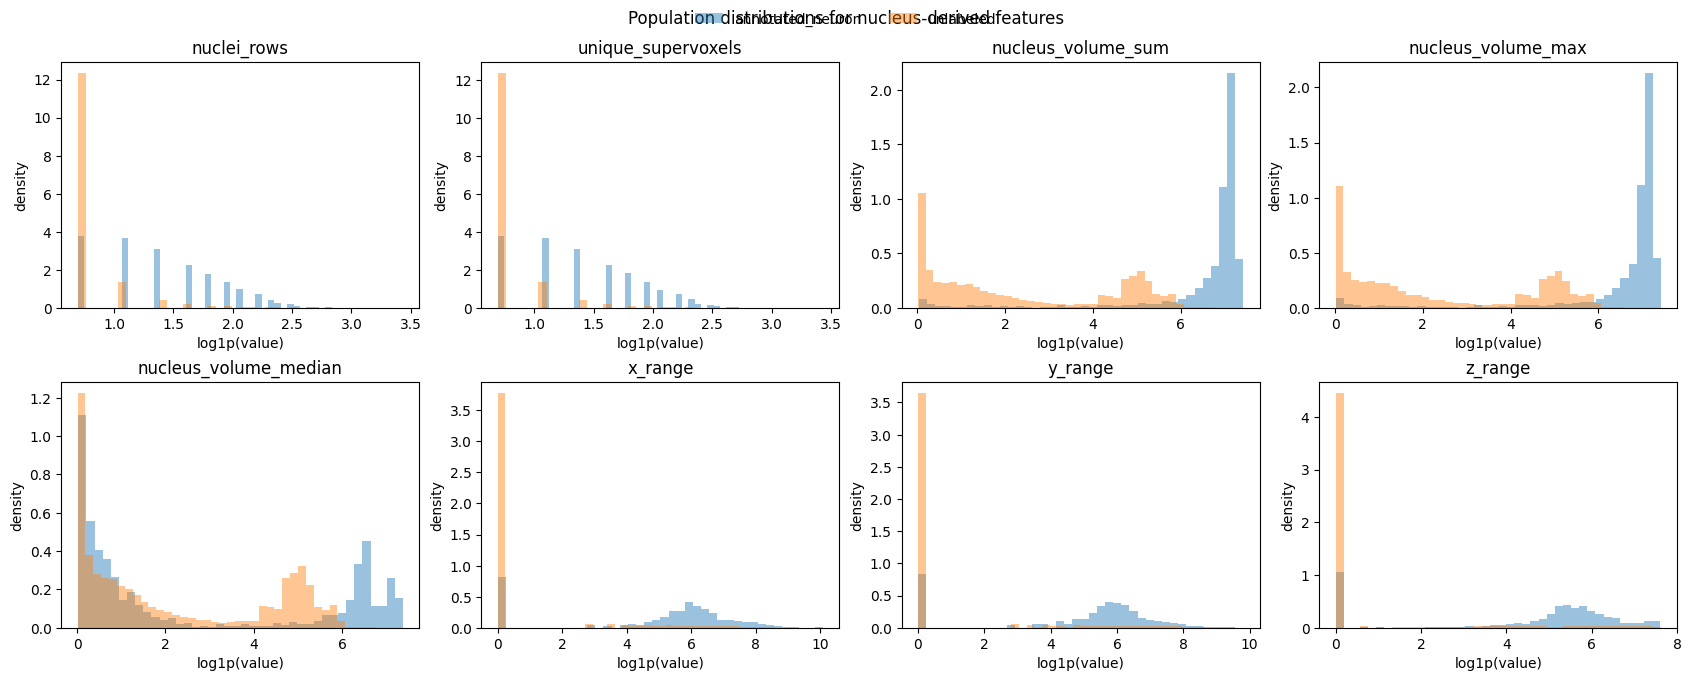

In [20]:
plot_feature_columns = selected_nucleus_feature_columns
population_order = ['annotated_neuron', 'unlabeled']
plot_colors = {
    'annotated_neuron': '#1f77b4',
    'unlabeled': '#ff7f0e',
}

n_features = len(plot_feature_columns)
n_cols = 4
n_rows = int(np.ceil(n_features / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.2 * n_rows), constrained_layout=True)
axes = np.asarray(axes).reshape(-1)

for ax, feature in zip(axes, plot_feature_columns):
    for population_label in population_order:
        values = pd.to_numeric(
            feature_source_df.loc[feature_source_df['population_label'] == population_label, feature],
            errors='coerce',
        ).dropna()
        values = values[np.isfinite(values)]
        ax.hist(
            np.log1p(values),
            bins=40,
            alpha=0.45,
            density=True,
            label=population_label,
            color=plot_colors.get(population_label),
        )
    ax.set_title(feature)
    ax.set_xlabel('log1p(value)')
    ax.set_ylabel('density')

for ax in axes[n_features:]:
    ax.set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(population_order), frameon=False)
fig.suptitle('Population distributions for nucleus-derived features', y=1.04)
plt.show()



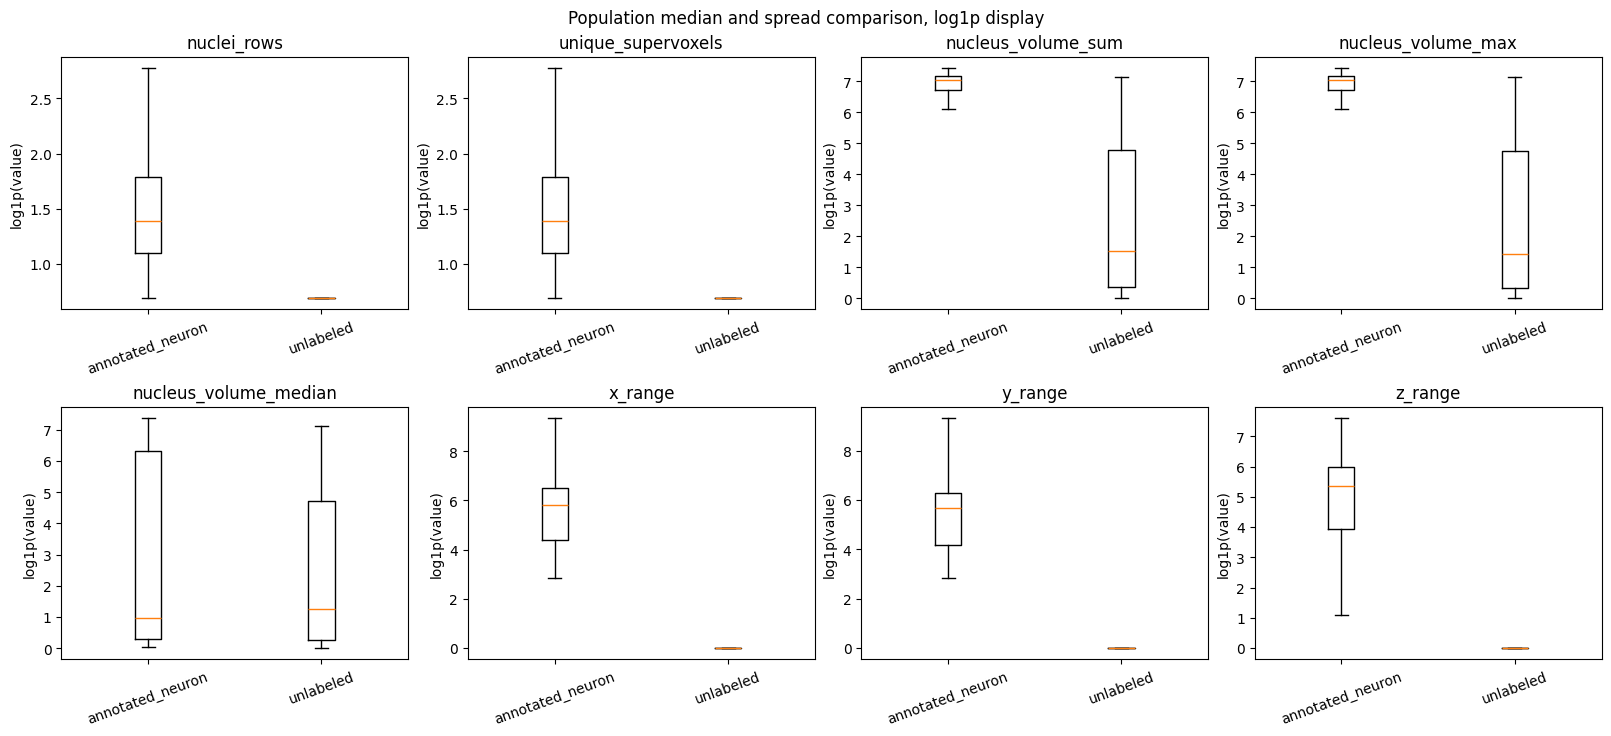

In [21]:
boxplot_feature_columns = selected_nucleus_feature_columns
fig, axes = plt.subplots(2, 4, figsize=(16, 7), constrained_layout=True)
axes = axes.reshape(-1)

for ax, feature in zip(axes, boxplot_feature_columns):
    data = []
    labels = []
    for population_label in population_order:
        values = pd.to_numeric(
            feature_source_df.loc[feature_source_df['population_label'] == population_label, feature],
            errors='coerce',
        ).dropna()
        values = values[np.isfinite(values)]
        data.append(np.log1p(values))
        labels.append(population_label)
    ax.boxplot(data, tick_labels=labels, showfliers=False)
    ax.set_title(feature)
    ax.set_ylabel('log1p(value)')
    ax.tick_params(axis='x', rotation=20)

for ax in axes[len(boxplot_feature_columns):]:
    ax.set_visible(False)

fig.suptitle('Population median and spread comparison, log1p display', y=1.03)
plt.show()



In [23]:
features_with_largest_median_ratio = []

if 'annotated_to_unlabeled_median_ratio' in feature_median_comparison_df.columns:

    ratio_series = pd.to_numeric(
        feature_median_comparison_df['annotated_to_unlabeled_median_ratio'],
        errors='coerce',
    )

    features_with_largest_median_ratio = (
        ratio_series
        .mask(~np.isfinite(ratio_series), np.nan)
        .dropna()
        .sub(1)
        .abs()
        .sort_values(ascending=False)
        .head(5)
        .index
        .tolist()
    )

print('features with largest annotated-vs-unlabeled median shifts:')
print(features_with_largest_median_ratio)

features with largest annotated-vs-unlabeled median shifts:
['nucleus_volume_max', 'nucleus_volume_sum', 'nuclei_rows', 'unique_supervoxels', 'nucleus_volume_median']


## Stage C Interpretation

The summary tables and side-by-side log-scaled plots highlight visible population differences worth following up. Features with large median shifts or visibly different distribution shapes should be treated as exploratory signals only. This section does not classify roots, does not infer that `unlabeled` roots are glia, and does not perform clustering, PCA/UMAP, or machine learning.


## Stage D: Volume Distributions and Manual Neuroglancer Samples

The volume-related summaries looked useful enough to explore interactively, so I tried a Plotly box/point visualization for `nucleus_volume_sum` and `nucleus_volume_max`. The root-ID samples and ranked lists support manual Neuroglancer inspection; `non_annotated` means the screened root is not present in the CA3 annotation CSV, with no biological identity inferred from that category.


In [24]:
volume_plot_features = ['nucleus_volume_sum', 'nucleus_volume_max']
volume_plot_df = feature_source_df[['pt_root_id', 'population_label'] + volume_plot_features].copy()
volume_plot_df['annotation_status'] = volume_plot_df['population_label'].map({
    'annotated_neuron': 'annotated',
    'unlabeled': 'non_annotated',
})

volume_plot_long_df = volume_plot_df.melt(
    id_vars=['pt_root_id', 'population_label', 'annotation_status'],
    value_vars=volume_plot_features,
    var_name='feature',
    value_name='value',
)

try:
    import plotly.express as px

    fig = px.box(
        volume_plot_long_df,
        x='feature',
        y='value',
        color='annotation_status',
        points='all',
        log_y=True,
        hover_data={
            'pt_root_id': True,
            'population_label': True,
            'annotation_status': True,
            'feature': True,
            'value': ':.4f',
        },
        category_orders={
            'annotation_status': ['annotated', 'non_annotated'],
            'feature': volume_plot_features,
        },
        title='Nucleus volume features by annotation status',
        labels={
            'feature': 'Feature',
            'value': 'Feature value, log scale',
            'annotation_status': 'Annotation status',
        },
    )
    fig.update_traces(jitter=0.35, pointpos=0, marker={'size': 3, 'opacity': 0.35})
    fig.update_layout(boxmode='group', height=650)
    fig.show()
except ImportError:
    import seaborn as sns
    import matplotlib.pyplot as plt

    g = sns.catplot(
        data=volume_plot_long_df,
        x='feature',
        y='value',
        hue='annotation_status',
        kind='box',
        showfliers=False,
        height=5,
        aspect=1.8,
    )
    sns.stripplot(
        data=volume_plot_long_df,
        x='feature',
        y='value',
        hue='annotation_status',
        dodge=True,
        alpha=0.25,
        size=2,
        ax=g.ax,
        legend=False,
    )
    g.ax.set_yscale('log')
    g.ax.set_title('Nucleus volume features by annotation status')
    g.ax.set_xlabel('Feature')
    g.ax.set_ylabel('Feature value, log scale')
    plt.show()



In [25]:
manual_sample_n = 20
manual_sample_random_state = 195

annotated_sample_root_ids = (
    feature_source_df.loc[feature_source_df['population_label'] == 'annotated_neuron', 'pt_root_id']
    .dropna()
    .astype(int)
    .sample(
        n=min(manual_sample_n, int((feature_source_df['population_label'] == 'annotated_neuron').sum())),
        random_state=manual_sample_random_state,
    )
    .sort_values()
    .tolist()
)

non_annotated_sample_root_ids = (
    feature_source_df.loc[feature_source_df['population_label'] != 'annotated_neuron', 'pt_root_id']
    .dropna()
    .astype(int)
    .sample(
        n=min(manual_sample_n, int((feature_source_df['population_label'] != 'annotated_neuron').sum())),
        random_state=manual_sample_random_state,
    )
    .sort_values()
    .tolist()
)

print(f'annotated random sample root IDs, n={len(annotated_sample_root_ids)}:')
print(annotated_sample_root_ids)
print(f'non-annotated random sample root IDs, n={len(non_annotated_sample_root_ids)}:')
print(non_annotated_sample_root_ids)



annotated random sample root IDs, n=20:
[648518346436330132, 648518346436917584, 648518346437410822, 648518346438205880, 648518346440507942, 648518346441129943, 648518346442272048, 648518346443421503, 648518346444258760, 648518346444857878, 648518346445041174, 648518346445640892, 648518346446085737, 648518346446136315, 648518346448253355, 648518346449413235, 648518346449759921, 648518346451003572, 648518346452074950, 648518346453796122]
non-annotated random sample root IDs, n=20:
[648518346345651356, 648518346371944493, 648518346408176942, 648518346418806065, 648518346422616694, 648518346428242298, 648518346429344112, 648518346432140328, 648518346433125683, 648518346433842259, 648518346433937193, 648518346436007882, 648518346436037380, 648518346440370004, 648518346445111657, 648518346445419112, 648518346447219380, 648518346449800979, 648518346451934851, 648518346461650926]


In [26]:
sum_thresh = 100
manual_sample_n = 20
manual_sample_random_state = 195

non_annotated_high_sum_pool_df = feature_source_df[
    (feature_source_df['population_label'] != 'annotated_neuron') &
    (feature_source_df['nucleus_volume_sum'] > sum_thresh)
].copy()

non_annotated_high_sum_sample_root_ids = (
    non_annotated_high_sum_pool_df['pt_root_id']
    .dropna()
    .astype(int)
    .sample(
        n=min(manual_sample_n, len(non_annotated_high_sum_pool_df)),
        random_state=manual_sample_random_state,
    )
    .sort_values()
    .tolist()
)

print(
    f'non-annotated roots with nucleus_volume_sum > {sum_thresh}: '
    f'{len(non_annotated_high_sum_pool_df)}'
)
print(f'random sample root IDs, n={len(non_annotated_high_sum_sample_root_ids)}:')
print(non_annotated_high_sum_sample_root_ids)



non-annotated roots with nucleus_volume_sum > 100: 3332
random sample root IDs, n=20:
[648518346424673630, 648518346429478750, 648518346429507570, 648518346430954962, 648518346435640753, 648518346436005578, 648518346436592969, 648518346438011805, 648518346439407708, 648518346440270221, 648518346440294940, 648518346440679014, 648518346440781806, 648518346441056689, 648518346441837477, 648518346443231473, 648518346444550163, 648518346444962299, 648518346445942744, 648518346472513958]


In [27]:
top_nucleus_volume_n = 100
top_nucleus_volume_sort_ascending = False

annotated_top_nucleus_volume_df = (
    feature_source_df.loc[
        feature_source_df['population_label'] == 'annotated_neuron',
        ['pt_root_id', 'population_label', 'nucleus_volume_sum'],
    ]
    .dropna(subset=['pt_root_id', 'nucleus_volume_sum'])
    .sort_values(
        'nucleus_volume_sum',
        ascending=top_nucleus_volume_sort_ascending,
    )
    .head(top_nucleus_volume_n)
    .copy()
)

annotated_top_nucleus_volume_root_ids = (
    annotated_top_nucleus_volume_df['pt_root_id']
    .astype(int)
    .tolist()
)

print(
    f'annotated root IDs sorted by nucleus_volume_sum, '
    f'n={len(annotated_top_nucleus_volume_root_ids)}, '
    f'ascending={top_nucleus_volume_sort_ascending}:'
)
print(annotated_top_nucleus_volume_root_ids)
display(annotated_top_nucleus_volume_df)


annotated root IDs sorted by nucleus_volume_sum, n=100, ascending=False:
[648518346442419701, 648518346437232646, 648518346436695831, 648518346442571721, 648518346439575644, 648518346440894353, 648518346431683520, 648518346442010597, 648518346452485350, 648518346437496155, 648518346440942118, 648518346431533987, 648518346447704211, 648518346444557287, 648518346451361634, 648518346440738406, 648518346454678665, 648518346451022260, 648518346465796078, 648518346440734822, 648518346457349234, 648518346449445235, 648518346442090245, 648518346436698777, 648518346454360140, 648518346449469764, 648518346441388758, 648518346440149399, 648518346446962610, 648518346436805246, 648518346449759921, 648518346441998053, 648518346440940582, 648518346449459524, 648518346436797822, 648518346445010973, 648518346444800804, 648518346440489648, 648518346438814610, 648518346444263880, 648518346439317859, 648518346446683356, 648518346433650771, 648518346443659243, 648518346454034369, 648518346439128988, 648518

,pt_root_id,population_label,nucleus_volume_sum
8820,648518346442419701,annotated_neuron,1682.631836
5814,648518346437232646,annotated_neuron,1607.396362
5501,648518346436695831,annotated_neuron,1598.546509
8900,648518346442571721,annotated_neuron,1593.985474
7218,648518346439575644,annotated_neuron,1542.197266
...,...,...,...
9660,648518346444241096,annotated_neuron,1431.61145
9684,648518346444264392,annotated_neuron,1430.913452
10739,648518346446691548,annotated_neuron,1430.528931
13858,648518346478162598,annotated_neuron,1430.487915


In [28]:
top_nucleus_volume_n = 20
top_nucleus_volume_sort_ascending = False

non_annotated_top_nucleus_volume_df = (
    feature_source_df.loc[
        feature_source_df['population_label'] != 'annotated_neuron',
        ['pt_root_id', 'population_label', 'nucleus_volume_sum'],
    ]
    .dropna(subset=['pt_root_id', 'nucleus_volume_sum'])
    .sort_values(
        'nucleus_volume_sum',
        ascending=top_nucleus_volume_sort_ascending,
    )
    .head(top_nucleus_volume_n)
    .copy()
)

non_annotated_top_nucleus_volume_root_ids = (
    non_annotated_top_nucleus_volume_df['pt_root_id']
    .astype(int)
    .tolist()
)

print(
    f'non-annotated root IDs sorted by nucleus_volume_sum, '
    f'n={len(non_annotated_top_nucleus_volume_root_ids)}, '
    f'ascending={top_nucleus_volume_sort_ascending}:'
)
print(non_annotated_top_nucleus_volume_root_ids)
display(non_annotated_top_nucleus_volume_df)


non-annotated root IDs sorted by nucleus_volume_sum, n=20, ascending=False:
[648518346443173292, 648518346438737689, 648518346440208816, 648518346441591259, 648518346437104007, 648518346439852695, 648518346445955534, 648518346444916979, 648518346455348332, 648518346447050442, 648518346445848425, 648518346451989245, 648518346433752659, 648518346443969657, 648518346439990677, 648518346438222248, 648518346433641043, 648518346424844545, 648518346429415362, 648518346462074755]


,pt_root_id,population_label,nucleus_volume_sum
9185,648518346443173292,unlabeled,1258.916992
6734,648518346438737689,unlabeled,1107.083374
7538,648518346440208816,unlabeled,1037.86084
8309,648518346441591259,unlabeled,970.784485
5741,648518346437104007,unlabeled,941.99585
7358,648518346439852695,unlabeled,935.269897
10434,648518346445955534,unlabeled,877.311951
10016,648518346444916979,unlabeled,839.998352
12941,648518346455348332,unlabeled,834.119751
10921,648518346447050442,unlabeled,819.79071


## Stage E: Coordinate Distributions and Boundary-Bounds Check

I tested whether spatial location differed by annotation status using existing root-level coordinate extent columns. Representative root positions are computed as midpoint coordinates from each root's observed nucleus-coordinate min/max values, but I did not interpret apparent edge enrichment because true Pyr volume bounds were not available.


In [29]:
position_source_df = screened_root_with_annotation_df.copy()

position_extent_columns = ['x_min', 'x_max', 'y_min', 'y_max', 'z_min', 'z_max']
available_position_extent_columns = [
    column for column in position_extent_columns
    if column in position_source_df.columns
]

print('joined dataframe shape:')
print(position_source_df.shape)
print('available root-level position extent columns:')
print(available_position_extent_columns)
print('population labels:')
print(position_source_df['population_label'].value_counts().to_dict())



joined dataframe shape:
(13860, 25)
available root-level position extent columns:
['x_min', 'x_max', 'y_min', 'y_max', 'z_min', 'z_max']
population labels:
{'unlabeled': 11799, 'annotated_neuron': 2061}


In [30]:
required_position_extent_columns = set(position_extent_columns)
if not required_position_extent_columns.issubset(position_source_df.columns):
    missing_columns = sorted(required_position_extent_columns - set(position_source_df.columns))
    raise ValueError(f'Missing required position extent columns: {missing_columns}')

representative_position_df = position_source_df.copy()
for axis in ['x', 'y', 'z']:
    representative_position_df[f'{axis}_mid'] = (
        pd.to_numeric(representative_position_df[f'{axis}_min'], errors='coerce') +
        pd.to_numeric(representative_position_df[f'{axis}_max'], errors='coerce')
    ) / 2

representative_position_columns = ['x_mid', 'y_mid', 'z_mid']

position_quality_rows = []
for column in representative_position_columns + position_extent_columns:
    values = pd.to_numeric(representative_position_df[column], errors='coerce')
    position_quality_rows.append({
        'column': column,
        'missing_count': int(values.isna().sum()),
        'nonfinite_count': int((~np.isfinite(values.to_numpy(dtype='float64', na_value=np.nan)) & values.notna().to_numpy()).sum()),
        'min_observed': values.min(),
        'max_observed': values.max(),
    })

position_quality_df = pd.DataFrame(position_quality_rows)

print('position column quality checks:')
display(position_quality_df)

print('representative position preview:')
display(
    representative_position_df[
        ['pt_root_id', 'population_label'] + representative_position_columns + position_extent_columns
    ].head(10)
)



position column quality checks:


,column,missing_count,nonfinite_count,min_observed,max_observed
0,x_mid,0,0,20592.0,71904.0
1,y_mid,0,0,19840.0,76368.0
2,z_mid,0,0,96.0,2142.0
3,x_min,0,0,20592.0,71904.0
4,x_max,0,0,20592.0,71904.0
5,y_min,0,0,19840.0,76368.0
6,y_max,0,0,19840.0,76368.0
7,z_min,0,0,96.0,2142.0
8,z_max,0,0,96.0,2142.0


representative position preview:


,pt_root_id,population_label,x_mid,y_mid,z_mid,x_min,x_max,y_min,y_max,z_min,z_max
0,648518346341364951,unlabeled,64112.0,32240.0,1028.5,64112,64112,32240,32240,1020,1037
1,648518346341389635,unlabeled,65824.0,41008.0,101.0,65824,65824,41008,41008,101,101
2,648518346341403465,unlabeled,65792.0,40560.0,113.0,65792,65792,40560,40560,113,113
3,648518346341404984,unlabeled,70000.0,60512.0,1947.0,70000,70000,60512,60512,1947,1947
4,648518346341407020,unlabeled,65760.0,41200.0,188.0,65760,65760,41200,41200,188,188
5,648518346341435752,unlabeled,43872.0,66208.0,1480.0,43872,43872,66208,66208,1480,1480
6,648518346341438764,unlabeled,65696.0,41216.0,503.0,65696,65696,41216,41216,503,503
7,648518346341448163,unlabeled,61792.0,40176.0,1359.0,61792,61792,40176,40176,1359,1359
8,648518346341505603,unlabeled,65728.0,41120.0,406.0,65728,65728,41120,41120,406,406
9,648518346341568741,unlabeled,45152.0,49760.0,1820.0,45152,45152,49760,49760,1820,1820


In [31]:
position_quantile_rows = []
position_quantiles = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]

for population_label, population_df in representative_position_df.groupby('population_label'):
    for coordinate_column in representative_position_columns:
        values = pd.to_numeric(population_df[coordinate_column], errors='coerce')
        row = {
            'population_label': population_label,
            'coordinate': coordinate_column,
            'count': int(values.notna().sum()),
            'mean': values.mean(),
            'median': values.median(),
            'min': values.min(),
            'max': values.max(),
        }
        for quantile in position_quantiles:
            row[f'p{int(quantile * 100):02d}'] = values.quantile(quantile)
        position_quantile_rows.append(row)

position_quantile_summary_df = pd.DataFrame(position_quantile_rows)

print('representative coordinate quantiles by population:')
display(position_quantile_summary_df)



representative coordinate quantiles by population:


,population_label,coordinate,count,mean,median,min,max,p01,p05,p10,p25,p50,p75,p90,p95,p99
0,annotated_neuron,x_mid,2061,45133.457545,44592.0,23560.0,68720.0,28534.4,30760.0,32120.0,35992.0,44592.0,53848.0,59384.0,60976.0,62769.60
1,annotated_neuron,y_mid,2061,55273.350801,54528.0,20800.0,75952.0,29849.6,39400.0,42664.0,48184.0,54528.0,62744.0,70160.0,72656.0,74947.20
2,annotated_neuron,z_mid,2061,1042.548520,1010.0,97.0,2139.5,124.0,186.0,261.5,531.0,1010.0,1512.0,1912.0,2024.0,2117.00
3,unlabeled,x_mid,11799,51734.266294,53056.0,20592.0,71904.0,22416.0,24871.2,30160.0,41372.0,53056.0,64720.0,69555.2,70752.0,71712.00
4,unlabeled,y_mid,11799,50908.445122,51376.0,19840.0,76368.0,20752.0,24624.0,28928.0,37792.0,51376.0,65392.0,71680.0,73680.0,75088.32
5,unlabeled,z_mid,11799,1160.528477,1178.0,96.0,2142.0,107.0,170.0,288.0,659.5,1178.0,1673.0,1992.6,2087.0,2135.02


In [32]:
position_plot_long_df = representative_position_df[
    ['pt_root_id', 'population_label'] + representative_position_columns
].melt(
    id_vars=['pt_root_id', 'population_label'],
    value_vars=representative_position_columns,
    var_name='axis',
    value_name='representative_position',
)

try:
    import plotly.express as px

    fig = px.histogram(
        position_plot_long_df,
        x='representative_position',
        color='population_label',
        facet_row='axis',
        histnorm='probability density',
        barmode='overlay',
        opacity=0.55,
        nbins=80,
        hover_data={
            'pt_root_id': True,
            'population_label': True,
            'axis': True,
            'representative_position': ':.2f',
        },
        category_orders={
            'population_label': ['annotated_neuron', 'unlabeled'],
            'axis': representative_position_columns,
        },
        title='Representative root-position distributions by population',
        labels={
            'representative_position': 'Representative root position, midpoint of observed nucleus extent',
            'population_label': 'Population label',
        },
    )
    fig.update_layout(height=850)
    fig.show()
except ImportError:
    import seaborn as sns
    import matplotlib.pyplot as plt

    g = sns.displot(
        data=position_plot_long_df,
        x='representative_position',
        hue='population_label',
        row='axis',
        kind='hist',
        stat='density',
        common_norm=False,
        bins=80,
        alpha=0.45,
        height=2.8,
        aspect=2.6,
    )
    g.fig.suptitle('Representative root-position distributions by population', y=1.02)
    plt.show()



In [33]:
import json

candidate_bound_variable_names = [
    name for name in globals()
    if any(token in name.lower() for token in ['bound', 'bbox', 'extent'])
]

print('candidate in-notebook/global names that may contain bounds:')
print(sorted(candidate_bound_variable_names))

candidate_metadata_paths = [
    project_root / 'data' / 'nuclei' / 'c3_nuclei_root_features_mat195_metadata.json',
    project_root / 'data' / 'nuclei' / 'c3_nuclei_v1_mat195_metadata.json',
]

metadata_bound_hits = []
for metadata_path in candidate_metadata_paths:
    if not metadata_path.exists():
        continue
    metadata = json.loads(metadata_path.read_text(encoding='utf-8'))
    for key, value in metadata.items():
        if any(token in key.lower() for token in ['bound', 'bbox', 'extent']):
            metadata_bound_hits.append({
                'metadata_path': format_path(metadata_path, project_root, show_full_path),
                'key': key,
                'value': value,
            })

print('metadata keys that appear to contain explicit bounds:')
if metadata_bound_hits:
    display(pd.DataFrame(metadata_bound_hits))
else:
    print([])

true_pyr_bounds_available = bool(metadata_bound_hits)
print(f'true Pyr volume bounds available in checked notebook variables/metadata: {true_pyr_bounds_available}')

if not true_pyr_bounds_available:
    print(
        'No explicit numeric Pyr volume bounds were found in the checked notebook variables or local metadata. '
        'Do not calculate distance-to-edge from observed coordinate min/max values.'
    )



candidate in-notebook/global names that may contain bounds:
['available_position_extent_columns', 'position_extent_columns', 'required_position_extent_columns']
metadata keys that appear to contain explicit bounds:
[]
true Pyr volume bounds available in checked notebook variables/metadata: False
No explicit numeric Pyr volume bounds were found in the checked notebook variables or local metadata. Do not calculate distance-to-edge from observed coordinate min/max values.


## Stage E Interpretation

The plots and quantile table above compare representative x/y/z root positions between `annotated_neuron` and `unlabeled` roots using existing root-level coordinate features. These are distribution comparisons only. The bounds metadata check prevents unsupported distance-to-edge conclusions: actual Pyr volume bounds were not assumed from observed coordinate minima or maxima, and no cells are classified or removed here.


## Stage F: Interactive 3D Spatial Overview

The tabular summaries, distribution plots, and 1D coordinate views were informative but did not directly show spatial organization. Here I moved to an interactive Plotly 3D scatterplot using one volume-weighted nucleus centroid per screened root. This became the most useful exploratory visualization in this notebook and motivated the cleaner Notebook 07 viewer.


In [34]:
centroid_candidate_columns = [
    column for column in screened_root_with_annotation_df.columns
    if any(token in column.lower() for token in ['centroid', 'center'])
]

print('screened joined dataframe shape:')
print(screened_root_with_annotation_df.shape)
print('centroid-like columns already present:')
print(centroid_candidate_columns)
print('available position extent columns:')
print([column for column in ['x_min', 'x_max', 'y_min', 'y_max', 'z_min', 'z_max'] if column in screened_root_with_annotation_df.columns])



screened joined dataframe shape:
(13860, 25)
centroid-like columns already present:
[]
available position extent columns:
['x_min', 'x_max', 'y_min', 'y_max', 'z_min', 'z_max']


In [35]:
nuclei_parquet_path = project_root / 'data' / 'nuclei' / 'c3_nuclei_v1_mat195.parquet'
centroid_voxel_columns = ['centroid_x_vox', 'centroid_y_vox', 'centroid_z_vox']

existing_centroid_column_sets = [
    ['centroid_x_vox', 'centroid_y_vox', 'centroid_z_vox'],
    ['x_centroid', 'y_centroid', 'z_centroid'],
    ['x_center', 'y_center', 'z_center'],
    ['x_mid', 'y_mid', 'z_mid'],
]

existing_centroid_columns = next(
    (columns for columns in existing_centroid_column_sets if set(columns).issubset(screened_root_with_annotation_df.columns)),
    None,
)

if existing_centroid_columns is not None:
    root_centroid_df = screened_root_with_annotation_df[['pt_root_id'] + existing_centroid_columns].copy()
    root_centroid_df = root_centroid_df.rename(columns=dict(zip(existing_centroid_columns, centroid_voxel_columns)))
    print(f'Using existing centroid columns: {existing_centroid_columns}')
else:
    print('No root-level centroid columns found; loading nuclei table to compute volume-weighted centroids.')
    nuclei_position_df = pd.read_parquet(
        nuclei_parquet_path,
        columns=['pt_root_id', 'pt_position', 'volume'],
    )
    nuclei_position_df = nuclei_position_df[nuclei_position_df['pt_root_id'] != 0].copy()
    nuclei_position_df['pt_root_id'] = pd.to_numeric(
        nuclei_position_df['pt_root_id'],
        errors='raise',
    ).astype('Int64')

    screened_root_id_set = set(screened_root_with_annotation_df['pt_root_id'].dropna().astype(int).tolist())
    nuclei_position_df = nuclei_position_df[nuclei_position_df['pt_root_id'].astype(int).isin(screened_root_id_set)].copy()

    position_xyz_df = pd.DataFrame(
        nuclei_position_df['pt_position'].tolist(),
        columns=centroid_voxel_columns,
        index=nuclei_position_df.index,
    )
    for column in centroid_voxel_columns:
        nuclei_position_df[column] = pd.to_numeric(position_xyz_df[column], errors='coerce')

    nuclei_position_df['centroid_weight'] = pd.to_numeric(
        nuclei_position_df['volume'],
        errors='coerce',
    ).fillna(0).clip(lower=0)

    for column in centroid_voxel_columns:
        nuclei_position_df[f'{column}_weighted'] = nuclei_position_df[column] * nuclei_position_df['centroid_weight']

    centroid_agg_df = (
        nuclei_position_df
        .groupby('pt_root_id')
        .agg(
            centroid_x_weighted_sum=('centroid_x_vox_weighted', 'sum'),
            centroid_y_weighted_sum=('centroid_y_vox_weighted', 'sum'),
            centroid_z_weighted_sum=('centroid_z_vox_weighted', 'sum'),
            centroid_weight_sum=('centroid_weight', 'sum'),
            centroid_x_mean=('centroid_x_vox', 'mean'),
            centroid_y_mean=('centroid_y_vox', 'mean'),
            centroid_z_mean=('centroid_z_vox', 'mean'),
            centroid_component_count=('pt_position', 'size'),
        )
        .reset_index()
    )

    for axis in ['x', 'y', 'z']:
        centroid_agg_df[f'centroid_{axis}_vox'] = np.where(
            centroid_agg_df['centroid_weight_sum'] > 0,
            centroid_agg_df[f'centroid_{axis}_weighted_sum'] / centroid_agg_df['centroid_weight_sum'],
            centroid_agg_df[f'centroid_{axis}_mean'],
        )

    root_centroid_df = centroid_agg_df[
        ['pt_root_id'] + centroid_voxel_columns + ['centroid_component_count', 'centroid_weight_sum']
    ].copy()

print('root centroid table shape:')
print(root_centroid_df.shape)
display(root_centroid_df.head())



No root-level centroid columns found; loading nuclei table to compute volume-weighted centroids.
root centroid table shape:
(13860, 6)


,pt_root_id,centroid_x_vox,centroid_y_vox,centroid_z_vox,centroid_component_count,centroid_weight_sum
0,648518346341364951,64112.00373,32240.001876,1032.541044,2,2.049131
1,648518346341389635,65824.00000,41008.000000,101.000000,1,0.612127
2,648518346341403465,65792.00000,40560.000000,113.000000,1,3.922837
3,648518346341404984,70000.00000,60512.000000,1947.000000,1,1.194394
4,648518346341407020,65760.00000,41200.000000,188.000000,1,1.593769


In [36]:
spatial_overview_df = screened_root_with_annotation_df.merge(
    root_centroid_df,
    on='pt_root_id',
    how='left',
    validate='one_to_one',
)

missing_centroid_mask = spatial_overview_df[centroid_voxel_columns].isna().any(axis=1)
missing_centroid_count = int(missing_centroid_mask.sum())

voxel_resolution_nm = {'x': 18, 'y': 18, 'z': 45}
for axis in ['x', 'y', 'z']:
    spatial_overview_df[f'centroid_{axis}_um'] = (
        pd.to_numeric(spatial_overview_df[f'centroid_{axis}_vox'], errors='coerce') *
        voxel_resolution_nm[axis] / 1000
    )

spatial_plot_df = spatial_overview_df[~missing_centroid_mask].copy()

print(f'screened roots before centroid merge: {len(screened_root_with_annotation_df)}')
print(f'screened roots after centroid merge: {len(spatial_overview_df)}')
print(f'missing-centroid roots: {missing_centroid_count}')
print(f'roots included in 3D plot: {len(spatial_plot_df)}')
print('population counts in 3D plot:')
print(spatial_plot_df['population_label'].value_counts().to_dict())

if missing_centroid_count > 0:
    print('root IDs missing centroids:')
    print(spatial_overview_df.loc[missing_centroid_mask, 'pt_root_id'].dropna().astype(int).tolist())



screened roots before centroid merge: 13860
screened roots after centroid merge: 13860
missing-centroid roots: 0
roots included in 3D plot: 13860
population counts in 3D plot:
{'unlabeled': 11799, 'annotated_neuron': 2061}


In [37]:
import plotly.graph_objects as go

population_plot_order = ['annotated_neuron', 'unlabeled']
population_plot_colors = {
    'annotated_neuron': '#1f77b4',
    'unlabeled': '#ff7f0e',
}
population_marker_opacity = {
    'annotated_neuron': 0.75,
    'unlabeled': 0.35,
}

nucleus_volume_size_transform = 'log'
nucleus_volume_marker_size_min = 2.0
nucleus_volume_marker_size_max = 12.0

def transform_nucleus_volume_for_marker_size(values, method):
    values = pd.to_numeric(values, errors='coerce').astype(float)
    method = method.lower() if isinstance(method, str) else method

    if method is None:
        transformed_values = values
    elif method in ['log', 'log10']:
        transformed_values = np.log10(values.where(values > 0))
    elif method == 'log1p':
        transformed_values = np.log1p(values.clip(lower=0))
    elif method == 'sqrt':
        transformed_values = np.sqrt(values.clip(lower=0))
    elif method in ['cuberoot', 'cube_root']:
        transformed_values = np.cbrt(values.clip(lower=0))
    elif method == 'rank':
        transformed_values = values.rank(pct=True)
    else:
        raise ValueError(
            "nucleus_volume_size_transform must be one of "
            "None, 'log', 'log10', 'log1p', 'sqrt', 'cuberoot', or 'rank'."
        )

    return transformed_values.replace([np.inf, -np.inf], np.nan)

nucleus_volume_size_values = transform_nucleus_volume_for_marker_size(
    spatial_plot_df['nucleus_volume_sum'],
    nucleus_volume_size_transform,
)
nucleus_volume_size_min = nucleus_volume_size_values.min(skipna=True)
nucleus_volume_size_max = nucleus_volume_size_values.max(skipna=True)

if pd.isna(nucleus_volume_size_min) or nucleus_volume_size_min == nucleus_volume_size_max:
    spatial_plot_df['nucleus_volume_marker_size'] = (
        nucleus_volume_marker_size_min + nucleus_volume_marker_size_max
    ) / 2
else:
    spatial_plot_df['nucleus_volume_marker_size'] = nucleus_volume_marker_size_min + (
        (nucleus_volume_size_values - nucleus_volume_size_min) /
        (nucleus_volume_size_max - nucleus_volume_size_min)
    ) * (nucleus_volume_marker_size_max - nucleus_volume_marker_size_min)
    spatial_plot_df['nucleus_volume_marker_size'] = spatial_plot_df['nucleus_volume_marker_size'].fillna(
        nucleus_volume_marker_size_min
    )

fig = go.Figure()
for population_label in population_plot_order:
    population_df = spatial_plot_df[spatial_plot_df['population_label'] == population_label].copy()
    if population_df.empty:
        continue

    customdata_columns = ['pt_root_id', 'population_label']
    for optional_column in ['nuclei_rows', 'nucleus_volume_sum']:
        if optional_column in population_df.columns:
            customdata_columns.append(optional_column)

    fig.add_trace(
        go.Scatter3d(
            x=population_df['centroid_x_um'],
            y=population_df['centroid_y_um'],
            z=population_df['centroid_z_um'],
            mode='markers',
            name=population_label,
            customdata=population_df[customdata_columns],
            marker={
                'size': population_df['nucleus_volume_marker_size'],
                'opacity': population_marker_opacity.get(population_label, 0.45),
                'color': population_plot_colors.get(population_label, '#666666'),
            },
            hovertemplate=(
                'root_id=%{customdata[0]}<br>'
                'population=%{customdata[1]}<br>'
                'nuclei_rows=%{customdata[2]}<br>'
                'nucleus_volume_sum=%{customdata[3]:.3f}<br>'
                'x=%{x:.2f} um<br>'
                'y=%{y:.2f} um<br>'
                'z=%{z:.2f} um'
                '<extra></extra>'
            ),
        )
    )

fig.update_layout(
    title=f'Screened root population centroid overview; marker size = nucleus_volume_sum ({nucleus_volume_size_transform})',
    scene={
        'xaxis_title': 'x centroid (um; 18 nm voxels)',
        'yaxis_title': 'y centroid (um; 18 nm voxels)',
        'zaxis_title': 'z centroid (um; 45 nm sections)',
        'aspectmode': 'data',
    },
    legend={
        'title': {'text': 'Population label'},
        'itemsizing': 'constant',
    },
    margin={'l': 0, 'r': 0, 'b': 0, 't': 45},
    height=800,
)

fig.show()



## Stage F Note

The 3D scatterplot is a spatial overview of screened roots using volume-weighted nucleus centroids in physical units. Legend entries can be toggled to hide either `annotated_neuron` or `unlabeled`, and marker size reflects `nucleus_volume_sum`. This view preserves all screened roots with available centroids and remains exploratory; Notebook 07 carries this direction forward in a cleaner visualization workflow.


## Stage G: Export 3D Centroid Plot

Export the existing Plotly 3D centroid figure to a standalone interactive HTML file for browser viewing. This section keeps the established filename and export behavior, then reports the local path instead of trying to open a browser automatically.


In [38]:
plotly_output_dir = project_root / 'outputs' / 'plotly'
plotly_output_dir.mkdir(parents=True, exist_ok=True)

centroid_plot_html_path = plotly_output_dir / 'screened_root_population_centroids_3d.html'

if centroid_plot_html_path.exists() and not overwrite_existing:
    print('Existing Plotly HTML found; keeping existing file.')
    print_path('Plotly HTML', centroid_plot_html_path, project_root, show_full_path)
else:
    fig.write_html(
        centroid_plot_html_path,
        include_plotlyjs=True,
        full_html=True,
    )

    print(f'Saved standalone interactive Plotly HTML: {format_path(centroid_plot_html_path, project_root, show_full_path)}')



Existing Plotly HTML found; keeping existing file.
Plotly HTML: outputs\plotly\screened_root_population_centroids_3d.html


In [39]:
print_path('Plotly HTML', centroid_plot_html_path, project_root, show_full_path)


Plotly HTML: outputs\plotly\screened_root_population_centroids_3d.html
